In [48]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [49]:
# This is the official implementation of the single-phase model for multi-class CVD classification presented in:
# Srikijkasemwat N, Villarroel M, Banerjee A,
# "Multi-Phase Deep Learning Model for Automated Disease Classification from Cardiac Cine MRI",
# Journal of the Royal Society Interface, 2025.
# Author: Srikijkasemwat N
# Date : August 27, 2025
#
# The training code based on:
# Chilamkurthy, S. "Transfer Learning for Computer Vision Tutorial."
# PyTorch Tutorials, https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# Accessed November 2023.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
cudnn.benchmark = True
from torchvision.io.image import read_image
from torchvision.transforms.functional import normalize, resize, to_pil_image

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, bilinear=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)

        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)

#### 1. Data Preparation for Oracle Multi-Phase Cardiac MRI Classification  
**Ground-Truth Full Mask Guidance for ED and ES**

This notebook builds an oracle multi-phase baseline by combining **ground-truth full-mask-guided ED inputs** and **ground-truth full-mask-guided ES inputs**.

The setup is simple:
- use the oracle ED cache for the ED branch
- use the oracle ES cache for the ES branch
- keep the same fusion architecture and training setup as the predicted-mask multi-phase model

This makes the comparison straightforward, because the main change is only the mask source.


In [55]:
import os
import json
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
ED_ORACLE_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\ED_oracle_gtfullmask_baseline_v1")
ES_ORACLE_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1")

MULTI_ORACLE_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\MULTI_oracle_gtfullmask_project_v1")
MULTI_ORACLE_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = MULTI_ORACLE_ROOT / "cache_multi_from_single_phase_oracle_gtfullmask_v1"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

ACDC_TRAIN_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\training")
ACDC_TEST_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\testing")

# ============================================================
# FIXED FOLDS
# ============================================================
train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

train_ids_fold = [train_ids_fold0, train_ids_fold1, train_ids_fold2, train_ids_fold3]
val_ids_fold   = [val_ids_fold0,   val_ids_fold1,   val_ids_fold2,   val_ids_fold3]

# ============================================================
# HELPERS
# ============================================================
def patient_name_from_id(pid0: int) -> str:
    return f"patient{pid0 + 1:03d}"

def parse_cfg(cfg_path: Path) -> dict:
    cfg = {}
    with open(cfg_path, "r", encoding="utf-8") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                cfg[k.strip()] = v.strip()
    return cfg

CLASS_MAP = {
    "NOR": "NOR",
    "MINF": "MI",
    "DCM": "DCM",
    "HCM": "HCM",
    "RV": "ARV",
}

CLASS_TO_IDX = {
    "ARV": 0,
    "DCM": 1,
    "HCM": 2,
    "MI": 3,
    "NOR": 4,
}

# ============================================================
# BUILD FOLD-SPECIFIC TRAIN / VAL / TEST INDEX
# ============================================================
for fold in range(4):
    fold_root = CACHE_ROOT / f"fold_{fold:02d}"
    fold_root.mkdir(parents=True, exist_ok=True)

    records = []

    # TRAIN
    for pid0 in train_ids_fold[fold]:
        patient = patient_name_from_id(pid0)

        ed_path = ED_ORACLE_ROOT / "cache_ed_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "train_all" / patient / "ED_oracle_gtfullmask.npy"
        es_path = ES_ORACLE_ROOT / "cache_es_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "train_all" / patient / "ES_oracle_gtfullmask.npy"

        cfg = parse_cfg(ACDC_TRAIN_DIR / patient / "Info.cfg")
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        if not ed_path.exists():
            raise FileNotFoundError(f"Missing ED segmented cache: {ed_path}")
        if not es_path.exists():
            raise FileNotFoundError(f"Missing ES segmented cache: {es_path}")

        records.append({
            "split": "train",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "ed_path": str(ed_path),
            "es_path": str(es_path),
        })

    # VAL
    for pid0 in val_ids_fold[fold]:
        patient = patient_name_from_id(pid0)

        ed_path = ED_ORACLE_ROOT / "cache_ed_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "train_all" / patient / "ED_oracle_gtfullmask.npy"
        es_path = ES_ORACLE_ROOT / "cache_es_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "train_all" / patient / "ES_oracle_gtfullmask.npy"

        cfg = parse_cfg(ACDC_TRAIN_DIR / patient / "Info.cfg")
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        if not ed_path.exists():
            raise FileNotFoundError(f"Missing ED segmented cache: {ed_path}")
        if not es_path.exists():
            raise FileNotFoundError(f"Missing ES segmented cache: {es_path}")

        records.append({
            "split": "val",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "ed_path": str(ed_path),
            "es_path": str(es_path),
        })

    # TEST
    for patient_dir in sorted(ACDC_TEST_DIR.iterdir()):
        if not patient_dir.is_dir() or not patient_dir.name.startswith("patient"):
            continue

        patient = patient_dir.name
        cfg = parse_cfg(patient_dir / "Info.cfg")
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        ed_path = ED_ORACLE_ROOT / "cache_ed_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "test" / patient / "ED_oracle_gtfullmask.npy"
        es_path = ES_ORACLE_ROOT / "cache_es_oracle_gtfullmask_v1" / f"fold_{fold:02d}" / "test" / patient / "ES_oracle_gtfullmask.npy"

        if not ed_path.exists():
            raise FileNotFoundError(f"Missing ED segmented test cache: {ed_path}")
        if not es_path.exists():
            raise FileNotFoundError(f"Missing ES segmented test cache: {es_path}")

        records.append({
            "split": "test",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "ed_path": str(ed_path),
            "es_path": str(es_path),
        })

    with open(fold_root / "cache_index.json", "w", encoding="utf-8") as f:
        json.dump(records, f, indent=2)

    print(f"Built fold {fold} index: {fold_root / 'cache_index.json'}")

Built fold 0 index: C:\Users\manoj\Desktop\Thesis\MULTI_segmented_project_aligned\cache_multi_from_single_phase_segmented\fold_00\cache_index.json
Built fold 1 index: C:\Users\manoj\Desktop\Thesis\MULTI_segmented_project_aligned\cache_multi_from_single_phase_segmented\fold_01\cache_index.json
Built fold 2 index: C:\Users\manoj\Desktop\Thesis\MULTI_segmented_project_aligned\cache_multi_from_single_phase_segmented\fold_02\cache_index.json
Built fold 3 index: C:\Users\manoj\Desktop\Thesis\MULTI_segmented_project_aligned\cache_multi_from_single_phase_segmented\fold_03\cache_index.json


### 2. Image Transformation pipeline


**Training Augmentation and Evaluation Preparation**

This section defines the transformation steps applied before the image is passed to the neural network.

The training pipeline includes controlled augmentation through brightness adjustment, contrast adjustment, and random rotation.  
After augmentation, a centre crop is applied, followed by resizing to 128 × 128, tensor conversion, and normalization.

For evaluation and testing, only deterministic processing is used so that performance is measured on stable and reproducible inputs.

In [52]:
from torchvision import transforms

# ============================================================
# SAME SEGMENTED ED/ES MODELS
# ============================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

paper_train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=[0.5, 1.5], contrast=[0.5, 1.5]),
    transforms.RandomRotation((-30, 30)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

paper_eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Oracle multi-phase transforms ready (V1).")
print("Final input size:", (128, 128))

Aligned transforms ready.
Final input size: (128, 128)


### 3. Dataset Construction for Oracle Multi-Phase Classification  
**Paired ED and ES Caches Built with Ground-Truth Full Mask Guidance**

This section builds the multi-phase dataset by pairing the cached oracle ED and oracle ES arrays for each patient.

For every patient, the dataset uses:
- **ground-truth ED mask** for ED slice selection, masking, and localisation
- **ground-truth ES mask** for ES slice selection, masking, and localisation

The downstream fusion model is left unchanged. So this notebook gives a direct upper-bound comparison against the predicted-mask multi-phase model.


In [56]:
import json
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

def minmax_to_uint8(img_2d: np.ndarray) -> np.ndarray:
    x = img_2d.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    x = (x * 255.0).clip(0, 255).astype(np.uint8)
    return x


class CachedSinglePhaseDataset(Dataset):
    def __init__(self, index_records, split, phase="ES", transform=None):
        assert phase in ["ED", "ES"]
        self.phase = phase
        self.transform = transform
        self.records = [r for r in index_records if r["split"] == split]
        self.classes = ["ARV", "DCM", "HCM", "MI", "NOR"]
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        arr = np.load(r["ed_path"] if self.phase == "ED" else r["es_path"]).astype(np.float32)
        arr_u8 = minmax_to_uint8(arr)
        img = Image.fromarray(arr_u8, mode="L").convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, r["label"]


class CachedMultiPhaseDataset(Dataset):
    def __init__(self, index_records, split, transform=None):
        self.transform = transform
        self.records = [r for r in index_records if r["split"] == split]
        self.classes = ["ARV", "DCM", "HCM", "MI", "NOR"]
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        ed_arr = np.load(r["ed_path"]).astype(np.float32)
        es_arr = np.load(r["es_path"]).astype(np.float32)

        ed_u8 = minmax_to_uint8(ed_arr)
        es_u8 = minmax_to_uint8(es_arr)

        ed_img = Image.fromarray(ed_u8, mode="L").convert("RGB")
        es_img = Image.fromarray(es_u8, mode="L").convert("RGB")

        if self.transform is not None:
            seed = np.random.randint(0, 2**31 - 1)
            torch.manual_seed(seed)
            ed_img = self.transform(ed_img)
            torch.manual_seed(seed)
            es_img = self.transform(es_img)

        return ed_img, es_img, r["label"]


fold_train_dataset_multi = {}
fold_val_dataset_multi = {}
fold_test_dataset_multi = {}

for fold in range(4):
    fold_index_path = CACHE_ROOT / f"fold_{fold:02d}" / "cache_index.json"
    with open(fold_index_path, "r", encoding="utf-8") as f:
        fold_index = json.load(f)

    fold_train_dataset_multi[fold] = CachedMultiPhaseDataset(
        fold_index, split="train", transform=paper_train_transform
    )
    fold_val_dataset_multi[fold] = CachedMultiPhaseDataset(
        fold_index, split="val", transform=paper_eval_transform
    )
    fold_test_dataset_multi[fold] = CachedMultiPhaseDataset(
        fold_index, split="test", transform=paper_eval_transform
    )

    print(
        f"Fold {fold} | "
        f"train: {len(fold_train_dataset_multi[fold])} | "
        f"val: {len(fold_val_dataset_multi[fold])} | "
        f"test: {len(fold_test_dataset_multi[fold])}"
    )

train_dataset_multi = fold_train_dataset_multi[0]
eval_train_dataset_multi = fold_val_dataset_multi[0]
test_dataset_multi = fold_test_dataset_multi[0]

Fold 0 | train: 75 | val: 25 | test: 50
Fold 1 | train: 75 | val: 25 | test: 50
Fold 2 | train: 75 | val: 25 | test: 50
Fold 3 | train: 75 | val: 25 | test: 50


In [58]:
# In our stratified k-fold cross-validation, we wanted to compare the performance of the different
# deep learning models on the same sets of 4 folds, so we defined all 4 folds and kept them
# consistent when training different models.

train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0 = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [ 0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1=[3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [ 0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2=[2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [ 0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3=[1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

In [59]:
train_ids_fold = []
train_ids_fold.append(train_ids_fold0)
train_ids_fold.append(train_ids_fold1)
train_ids_fold.append(train_ids_fold2)
train_ids_fold.append(train_ids_fold3)

val_ids_fold = []
val_ids_fold.append(val_ids_fold0)
val_ids_fold.append(val_ids_fold1)
val_ids_fold.append(val_ids_fold2)
val_ids_fold.append(val_ids_fold3)

In [60]:
import os
import json
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.models.feature_extraction import create_feature_extractor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    recall_score
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("\nStarting 4-fold training for oracle multi-phase GT full-mask model (V1)...\n")

class_names_multi = fold_train_dataset_multi[0].classes
print("Classes:", class_names_multi)

ED_CKPT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ED_oracle_gtfullmask_baseline_v1\checkpoints_ED_oracle_gtfullmask_v1")
ES_CKPT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\checkpoints_ES_oracle_gtfullmask_v1")

CKPT_DIR = "./checkpoints_multi_oracle_gtfullmask_v1"
FIG_DIR = "./figures_multi_oracle_gtfullmask_v1"
META_DIR = "./fold_meta_multi_oracle_gtfullmask_v1"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

num_epochs = 150
batch_size = 20
num_classes = 5
initial_lr = 1e-1

results_val_acc_multi_oracle_gtfullmask_v1 = {}
results_val_f1macro_multi_oracle_gtfullmask_v1 = {}
results_val_sensmacro_multi_oracle_gtfullmask_v1 = {}
results_val_specmacro_multi_oracle_gtfullmask_v1 = {}

def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))


class MultiPhaseConcatModel(nn.Module):
    def __init__(self, ed_backbone, es_backbone, num_classes=5):
        super().__init__()
        self.ed_features = create_feature_extractor(ed_backbone, return_nodes={"layer4": "feat"})
        self.es_features = create_feature_extractor(es_backbone, return_nodes={"layer4": "feat"})

        for p in self.ed_features.parameters():
            p.requires_grad = False
        for p in self.es_features.parameters():
            p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(40960, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_ed, x_es):
        feat_ed = self.ed_features(x_ed)["feat"]
        feat_es = self.es_features(x_es)["feat"]
        feat = torch.cat((feat_ed, feat_es), dim=1)
        return self.classifier(feat)


for fold in range(4):
    print(f"\n{'='*80}")
    print(f"FOLD {fold}")
    print(f"{'='*80}")

    trainloader = DataLoader(
        fold_train_dataset_multi[fold],
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    valloader = DataLoader(
        fold_val_dataset_multi[fold],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    dataloaders = {"train": trainloader, "val": valloader}
    dataset_sizes = {
        "train": len(fold_train_dataset_multi[fold]),
        "val": len(fold_val_dataset_multi[fold])
    }

    ed_ckpt_path = ED_CKPT_DIR / f"ED-oracle-gtfullmask-resnet34-best-fold-{fold}.pth"
    es_ckpt_path = ES_CKPT_DIR / f"ES-oracle-gtfullmask-resnet50-best-fold-{fold}.pth"

    ed_backbone = models.resnet34(weights="IMAGENET1K_V1")
    ed_backbone.fc = nn.Linear(ed_backbone.fc.in_features, num_classes)
    ed_backbone.load_state_dict(torch.load(ed_ckpt_path, map_location=device))
    ed_backbone = ed_backbone.to(device)
    ed_backbone.eval()

    es_backbone = models.resnet50(weights="IMAGENET1K_V1")
    es_backbone.fc = nn.Linear(es_backbone.fc.in_features, num_classes)
    es_backbone.load_state_dict(torch.load(es_ckpt_path, map_location=device))
    es_backbone = es_backbone.to(device)
    es_backbone.eval()

    model = MultiPhaseConcatModel(ed_backbone, es_backbone, num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.classifier.parameters(), lr=initial_lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_val_sens = 0.0
    best_val_spec = 0.0
    best_epoch = -1

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1:03d}/{num_epochs}", end="  ")

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_corrects = 0
            y_true_all = []
            y_pred_all = []

            for ed_inputs, es_inputs, labels in dataloaders[phase]:
                ed_inputs = ed_inputs.to(device)
                es_inputs = es_inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(ed_inputs, es_inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * labels.size(0)
                running_corrects += torch.sum(preds == labels.data)
                y_true_all.extend(labels.detach().cpu().numpy().tolist())
                y_pred_all.extend(preds.detach().cpu().numpy().tolist())

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            if phase == "train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
                print(f"train_acc={epoch_acc*100:.2f}%", end="  ")
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)

                val_f1_macro = f1_score(y_true_all, y_pred_all, average="macro")
                val_sens_macro = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
                val_spec_macro = macro_specificity_score(y_true_all, y_pred_all, num_classes=num_classes)

                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_val_f1 = val_f1_macro
                    best_val_sens = val_sens_macro
                    best_val_spec = val_spec_macro
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(best_model_wts, os.path.join(CKPT_DIR, f"combine-oracle-gtfullmask-resnet34-resnet50-SGD0.1-fold-{fold}.pth"))

                print(f"val_acc={epoch_acc*100:.2f}%  val_f1={val_f1_macro*100:.2f}%")

    model.load_state_dict(best_model_wts)

    results_val_acc_multi_oracle_gtfullmask_v1[fold] = float(best_val_acc * 100)
    results_val_f1macro_multi_oracle_gtfullmask_v1[fold] = float(best_val_f1 * 100)
    results_val_sensmacro_multi_oracle_gtfullmask_v1[fold] = float(best_val_sens * 100)
    results_val_specmacro_multi_oracle_gtfullmask_v1[fold] = float(best_val_spec * 100)

    with open(os.path.join(META_DIR, f"multi_fold_{fold}_meta.json"), "w", encoding="utf-8") as f:
        json.dump({
            "fold": fold,
            "best_epoch": int(best_epoch),
            "best_val_accuracy": float(best_val_acc * 100),
            "best_val_macro_f1": float(best_val_f1 * 100),
            "best_val_macro_sensitivity": float(best_val_sens * 100),
            "best_val_macro_specificity": float(best_val_spec * 100),
        }, f, indent=2)

print("\nTraining finished.")

Using device: cuda:0
Classes: ['ARV', 'DCM', 'HCM', 'MI', 'NOR']

FOLD 0
Epoch 001/150  train_acc=24.00%  val_acc=40.00%  val_f1=23.81%
Epoch 002/150  train_acc=45.33%  val_acc=28.00%  val_f1=16.36%
Epoch 003/150  train_acc=48.00%  val_acc=40.00%  val_f1=28.50%
Epoch 004/150  train_acc=52.00%  val_acc=52.00%  val_f1=50.64%
Epoch 005/150  train_acc=77.33%  val_acc=68.00%  val_f1=64.30%
Epoch 006/150  train_acc=68.00%  val_acc=36.00%  val_f1=26.67%
Epoch 007/150  train_acc=45.33%  val_acc=56.00%  val_f1=51.83%
Epoch 008/150  train_acc=66.67%  val_acc=44.00%  val_f1=38.50%
Epoch 009/150  train_acc=72.00%  val_acc=52.00%  val_f1=50.67%
Epoch 010/150  train_acc=86.67%  val_acc=52.00%  val_f1=39.63%
Epoch 011/150  train_acc=65.33%  val_acc=56.00%  val_f1=54.45%
Epoch 012/150  train_acc=73.33%  val_acc=44.00%  val_f1=43.44%
Epoch 013/150  train_acc=86.67%  val_acc=48.00%  val_f1=48.05%
Epoch 014/150  train_acc=89.33%  val_acc=52.00%  val_f1=52.88%
Epoch 015/150  train_acc=85.33%  val_acc=56.0


=== SINGLE RUN ON TEST SET (50 subjects) ===
Accuracy          : 66.00%
Macro F1-score    : 64.89%
Macro Sensitivity : 66.00%
Macro Specificity : 91.50%

Classification Report (Test Set):
              precision    recall  f1-score   support

         ARV     0.5294    0.9000    0.6667        10
         DCM     0.9000    0.9000    0.9000        10
         HCM     0.7000    0.7000    0.7000        10
          MI     0.8000    0.4000    0.5333        10
         NOR     0.5000    0.4000    0.4444        10

    accuracy                         0.6600        50
   macro avg     0.6859    0.6600    0.6489        50
weighted avg     0.6859    0.6600    0.6489        50



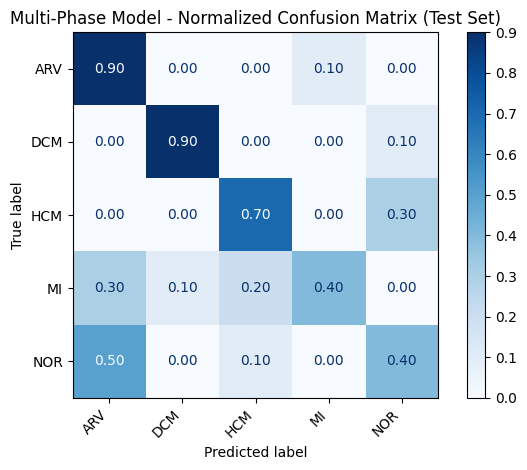


Running bootstrap resampling (n=1000)...

=== BOOTSTRAP TEST RESULTS (n=1000) ===
Accuracy          : 66.69 ± 7.05   (min 42.00 / max 88.00)
Macro F1-score    : 64.20 ± 7.02   (min 42.27 / max 86.58)
Macro Sensitivity : 66.40 ± 6.43   (min 46.16 / max 87.98)
Macro Specificity : 91.67 ± 1.76   (min 85.06 / max 97.00)


In [61]:
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models.feature_extraction import create_feature_extractor
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ED_CKPT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ED_oracle_gtfullmask_baseline_v1\checkpoints_ED_oracle_gtfullmask_v1")
ES_CKPT_DIR = Path(r"C:\Users\manoj\Desktop\Thesis\ES_oracle_gtfullmask_baseline_v1\checkpoints_ES_oracle_gtfullmask_v1")
MULTI_CKPT_DIR = Path("./checkpoints_multi_oracle_gtfullmask_v1")

class MultiPhaseConcatModel(nn.Module):
    def __init__(self, ed_backbone, es_backbone, num_classes=5):
        super().__init__()
        self.ed_features = create_feature_extractor(ed_backbone, return_nodes={"layer4": "feat"})
        self.es_features = create_feature_extractor(es_backbone, return_nodes={"layer4": "feat"})

        for p in self.ed_features.parameters():
            p.requires_grad = False
        for p in self.es_features.parameters():
            p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(40960, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_ed, x_es):
        feat_ed = self.ed_features(x_ed)["feat"]
        feat_es = self.es_features(x_es)["feat"]
        feat = torch.cat((feat_ed, feat_es), dim=1)
        return self.classifier(feat)


best_fold = max(results_val_f1macro_multi_oracle_gtfullmask_v1, key=results_val_f1macro_multi_oracle_gtfullmask_v1.get)

testloader_multi = DataLoader(
    fold_test_dataset_multi[best_fold],
    batch_size=25,
    shuffle=False,
    num_workers=0
)

ed_backbone = models.resnet34(weights="IMAGENET1K_V1")
ed_backbone.fc = nn.Linear(ed_backbone.fc.in_features, 5)
ed_backbone.load_state_dict(torch.load(ED_CKPT_DIR / f"ED-oracle-gtfullmask-resnet34-best-fold-{best_fold}.pth", map_location=device))
ed_backbone = ed_backbone.to(device)
ed_backbone.eval()

es_backbone = models.resnet50(weights="IMAGENET1K_V1")
es_backbone.fc = nn.Linear(es_backbone.fc.in_features, 5)
es_backbone.load_state_dict(torch.load(ES_CKPT_DIR / f"ES-oracle-gtfullmask-resnet50-best-fold-{best_fold}.pth", map_location=device))
es_backbone = es_backbone.to(device)
es_backbone.eval()

model_multi = MultiPhaseConcatModel(ed_backbone, es_backbone, num_classes=5)
model_multi.load_state_dict(torch.load(MULTI_CKPT_DIR / f"combine-oracle-gtfullmask-resnet34-resnet50-SGD0.1-fold-{best_fold}.pth", map_location=device))
model_multi = model_multi.to(device)
model_multi.eval()

class_names_multi = fold_train_dataset_multi[best_fold].classes

def eval_once_multi(dataloader, model):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for ed_inputs, es_inputs, labels in dataloader:
            ed_inputs = ed_inputs.to(device)
            es_inputs = es_inputs.to(device)
            outputs = model(ed_inputs, es_inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.tolist())
    return np.array(y_true), np.array(y_pred)

def macro_specificity_score(y_true, y_pred, num_classes=5):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def compute_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, f1_score, recall_score
    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro") * 100
    macro_sens = recall_score(y_true, y_pred, average="macro", zero_division=0) * 100
    macro_spec = macro_specificity_score(y_true, y_pred, num_classes=5) * 100
    return acc, macro_f1, macro_sens, macro_spec

def bootstrap_test_multi(dataloader, model, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true, y_pred = eval_once_multi(dataloader, model)
    n = len(y_true)

    boot_metrics = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]
        boot_metrics.append(compute_metrics(yt, yp))

    boot_metrics = np.array(boot_metrics)
    return (
        boot_metrics.mean(axis=0),
        boot_metrics.std(axis=0, ddof=1),
        boot_metrics.min(axis=0),
        boot_metrics.max(axis=0),
    )

y_true, y_pred = eval_once_multi(testloader_multi, model_multi)
acc, macro_f1, macro_sens, macro_spec = compute_metrics(y_true, y_pred)

print("\n=== SINGLE RUN ON TEST SET (50 subjects) ===")
print(f"Accuracy          : {acc:.2f}%")
print(f"Macro F1-score    : {macro_f1:.2f}%")
print(f"Macro Sensitivity : {macro_sens:.2f}%")
print(f"Macro Specificity : {macro_spec:.2f}%")

print("\nClassification Report (Test Set):")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names_multi,
    digits=4,
    zero_division=0
))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names_multi,
    cmap=plt.cm.Blues,
    normalize='true',
    values_format='.2f'
)
disp.ax_.set_title("Oracle Multi-Phase Model - Normalized Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Multi_test_normalized_confusion_matrix_oracle_gtfullmask_v1.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nRunning bootstrap resampling (n=1000)...")
mean, std, minv, maxv = bootstrap_test_multi(testloader_multi, model_multi, n_bootstrap=1000)

print("\n=== BOOTSTRAP TEST RESULTS (n=1000) ===")
print(f"Accuracy          : {mean[0]:.2f} ± {std[0]:.2f}   (min {minv[0]:.2f} / max {maxv[0]:.2f})")
print(f"Macro F1-score    : {mean[1]:.2f} ± {std[1]:.2f}   (min {minv[1]:.2f} / max {maxv[1]:.2f})")
print(f"Macro Sensitivity : {mean[2]:.2f} ± {std[2]:.2f}   (min {minv[2]:.2f} / max {maxv[2]:.2f})")
print(f"Macro Specificity : {mean[3]:.2f} ± {std[3]:.2f}   (min {minv[3]:.2f} / max {maxv[3]:.2f})")